In [1]:
import subprocess
import sys
import os

libraries = ["ultralytics"]

for lib in libraries:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", lib])


Defaulting to user installation because normal site-packages is not writeable
  Using cached ultralytics-8.4.7-py3-none-any.whl.metadata (38 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 4.3 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.3.233
    Uninstalling ultralytics-8.3.233:
      Successfully uninstalled ultralytics-8.3.233


In [2]:
CLUSTER = False
if not CLUSTER:
    HOME = "/Users/rubenhayrapetyan/Downloads/Code/FRC/machine-learning/2026-Rebuilt"
else:
    HOME = "/home/rhayrapetyan/2025-Coral_Detection_Training"
    os.makedirs(f"{HOME}/robot_detection/runs/train", exist_ok=True)


In [3]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')  # load a pretrained model (recommended for training)
if CLUSTER:
    os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'
    results = model.train(
        data=f"{HOME}/FRC 2024.v4i.yolov12/data.yaml",
        epochs=100,
        imgsz=640,
        batch=16,
        name="robot-detection-model-v1",
        device=[0,1],
        workers=2,
        project=f"{HOME}/robot_detection/runs/train"
    )    
else:
    results = model.train(
        data=f"/Users/rubenhayrapetyan/Downloads/Code/FRC/machine-learning/2026-Rebuilt/merged/data.yaml",
        epochs=100,
        imgsz=640,
        batch=16,
        name="robot-detection-model-v1",
        workers=8,
        project=f"{HOME}/robot_detection/runs/train"
    )

metrics = model.val(split="test")

/Users/rubenhayrapetyan/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Ultralytics 8.4.7 🚀 Python-3.9.6 torch-2.8.0 CPU (Apple M3 Max)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/rubenhayrapetyan/Downloads/Code/FRC/machine-learning/2026-Rebuilt/merged/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=robot-detection-model-v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto

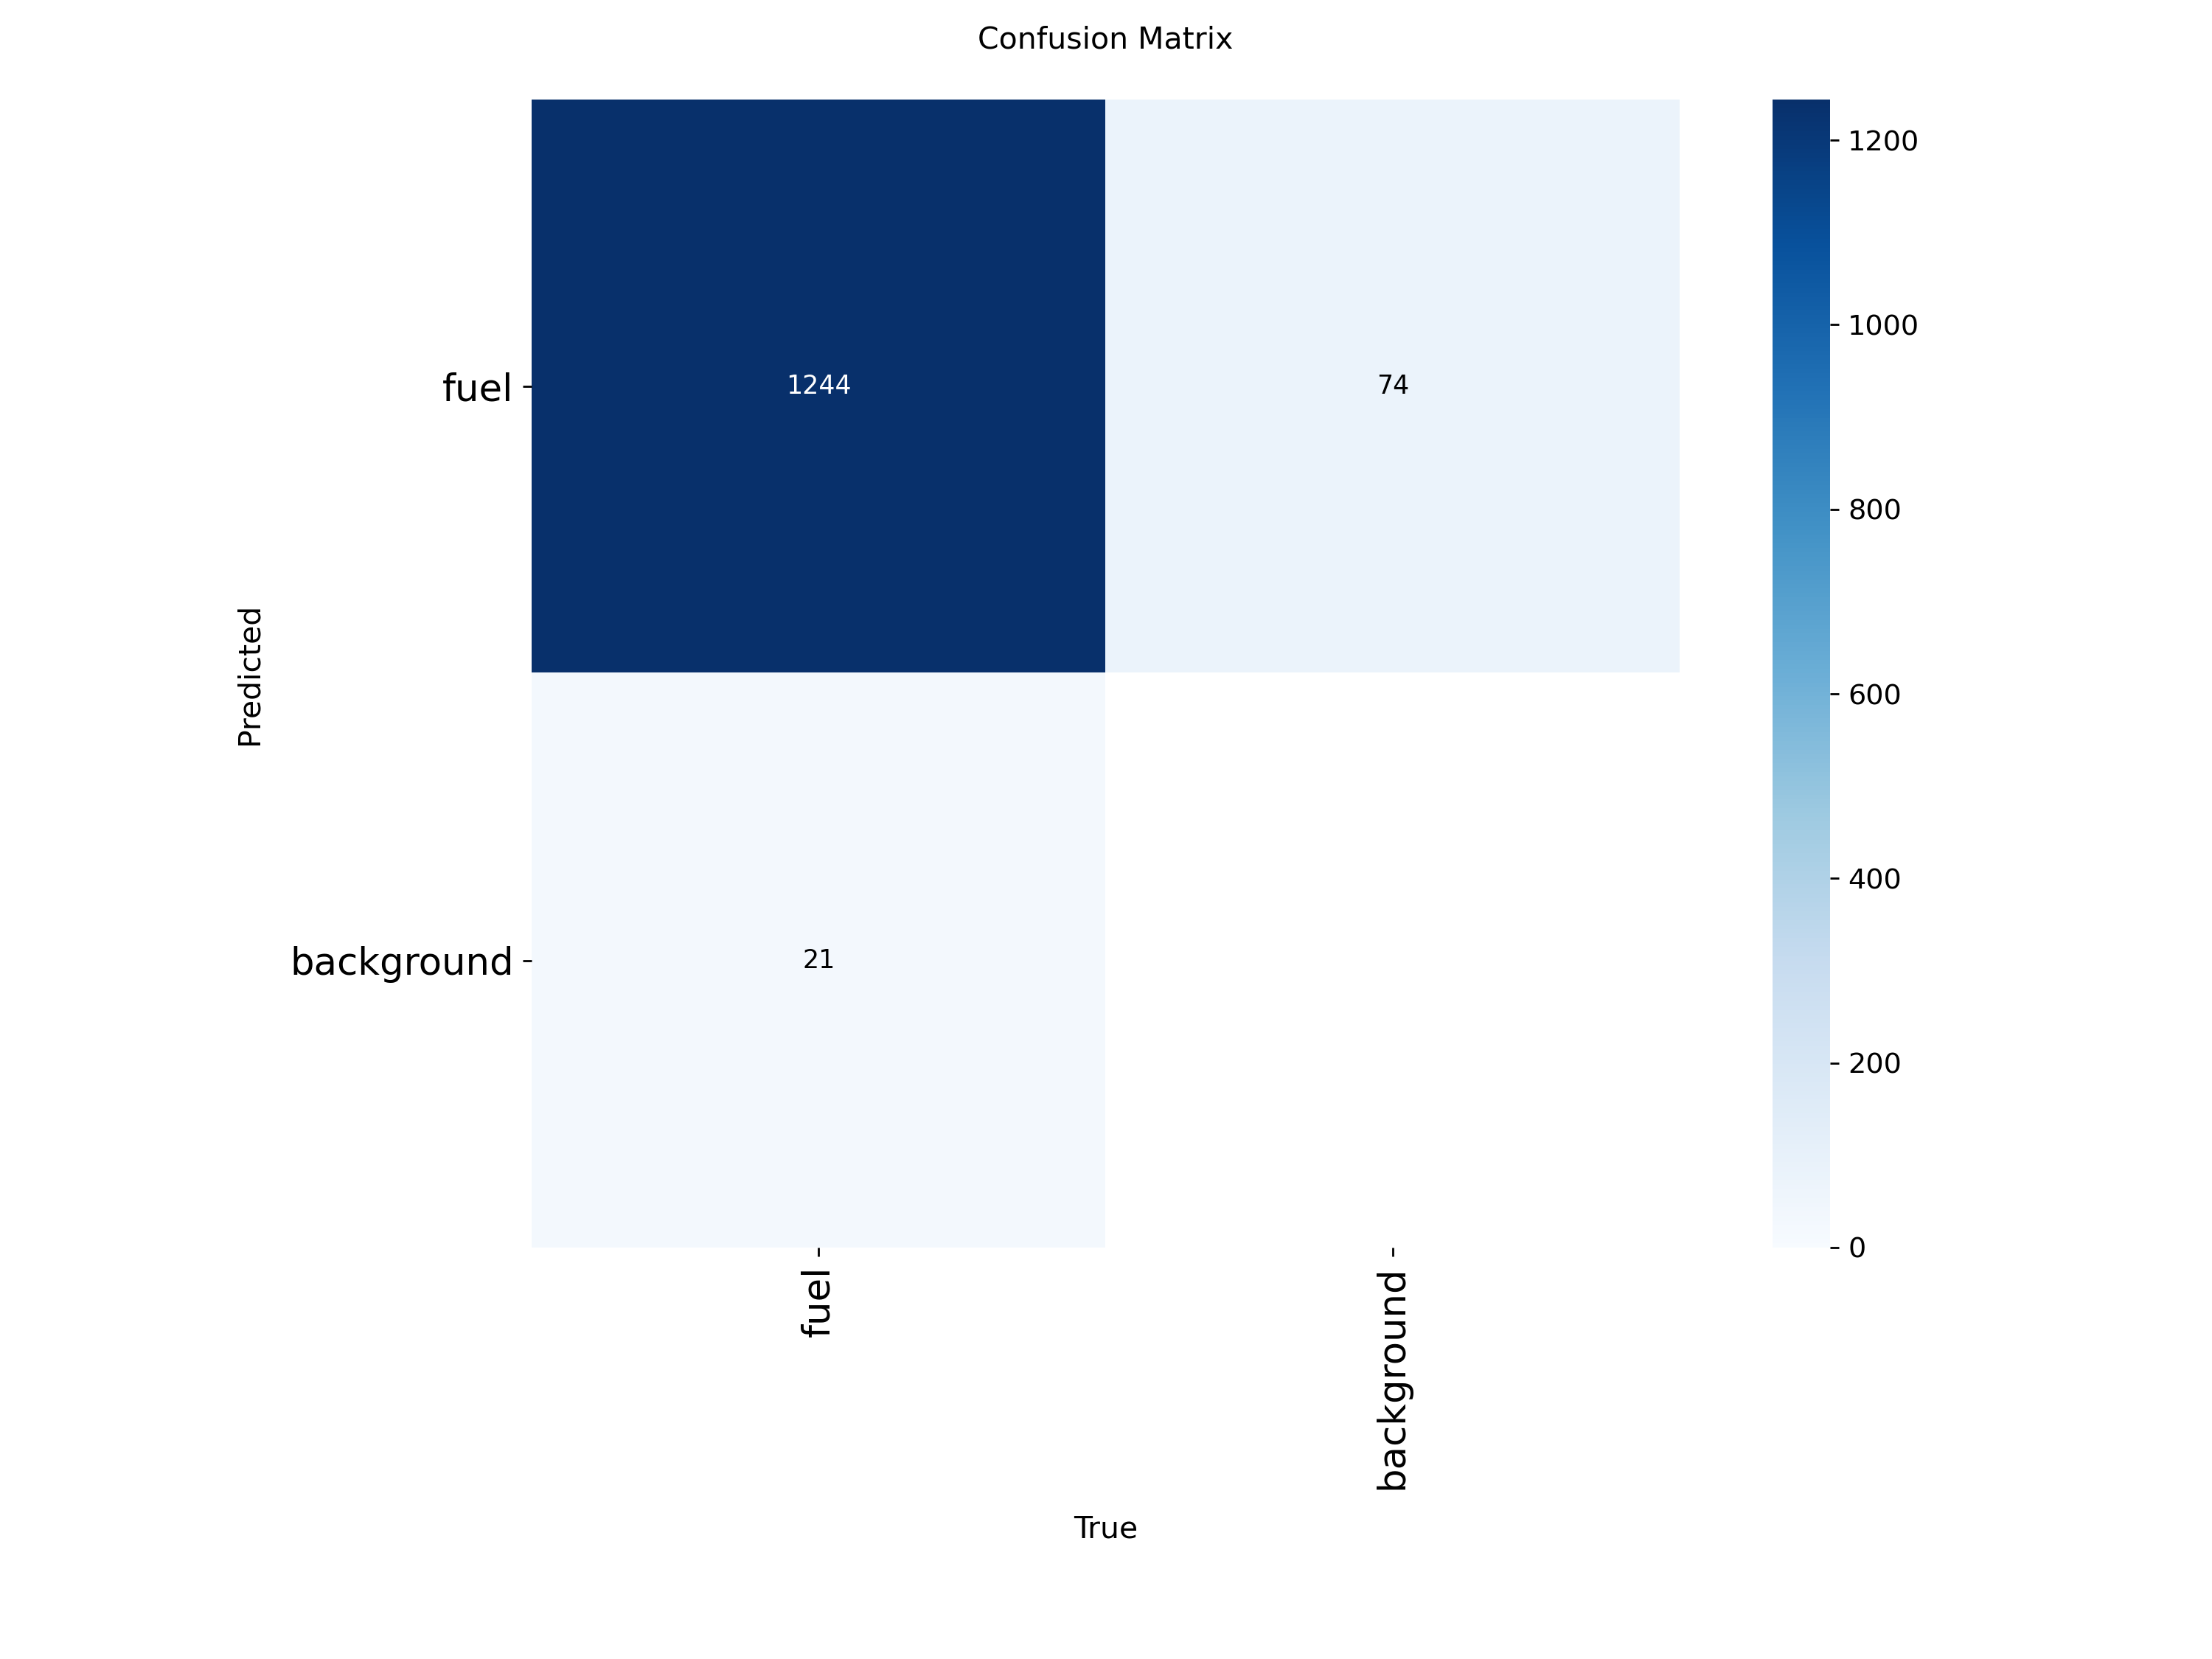

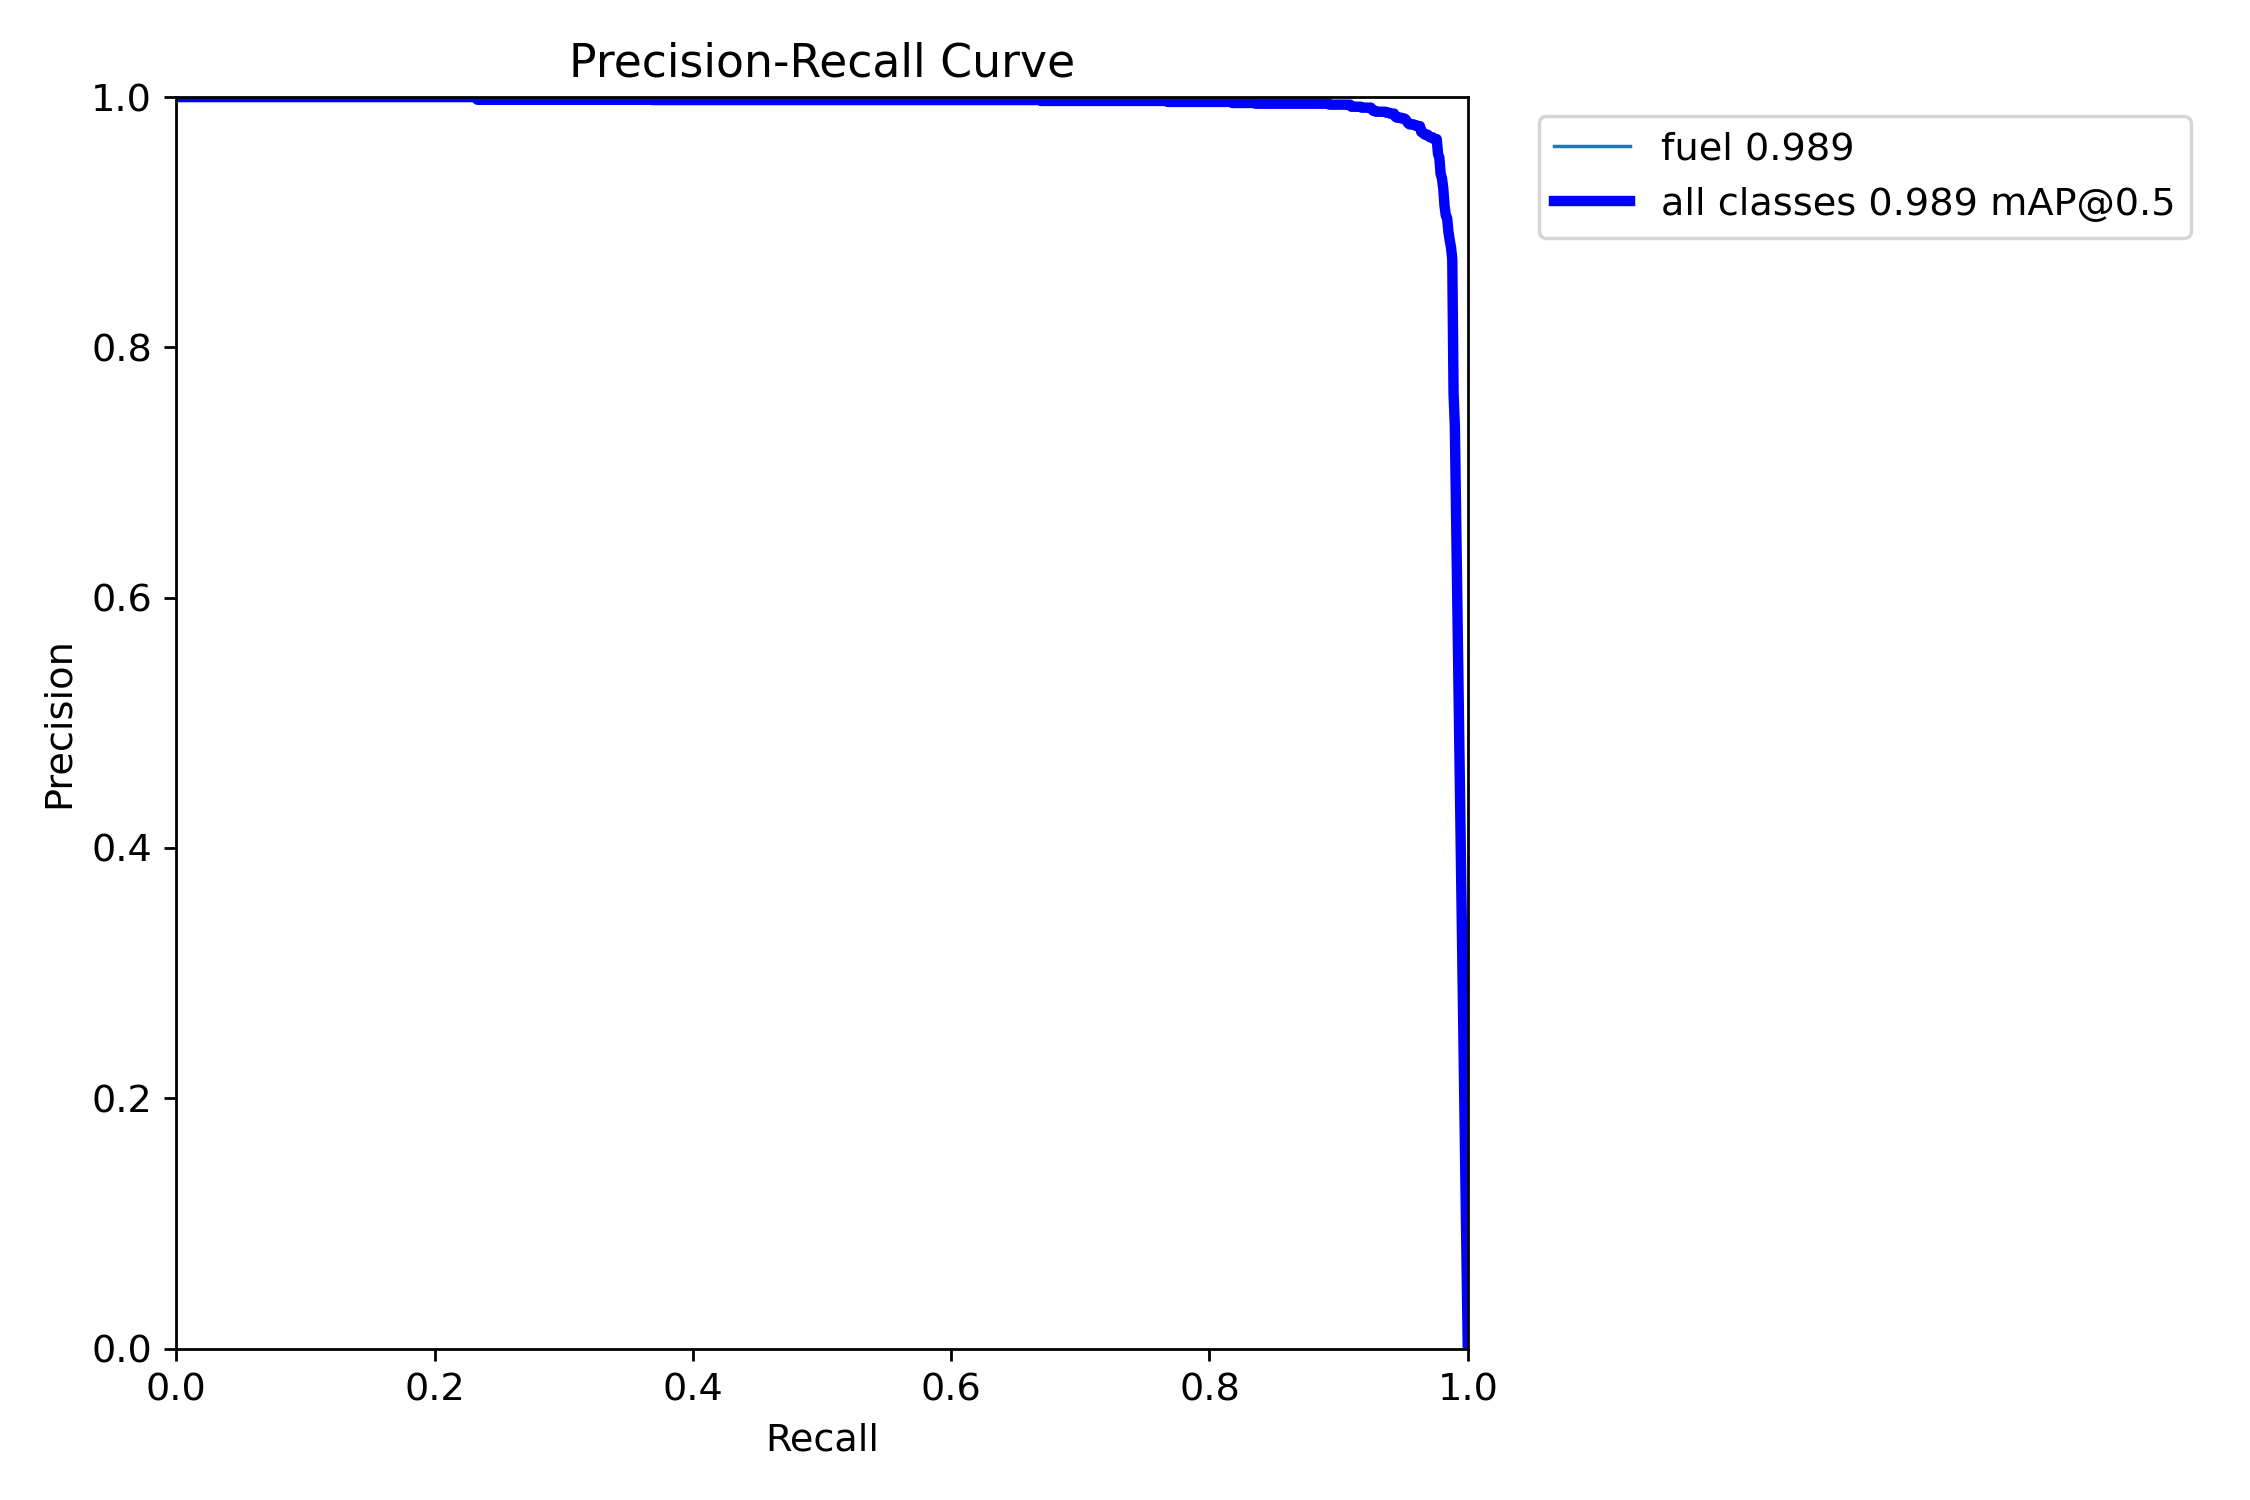

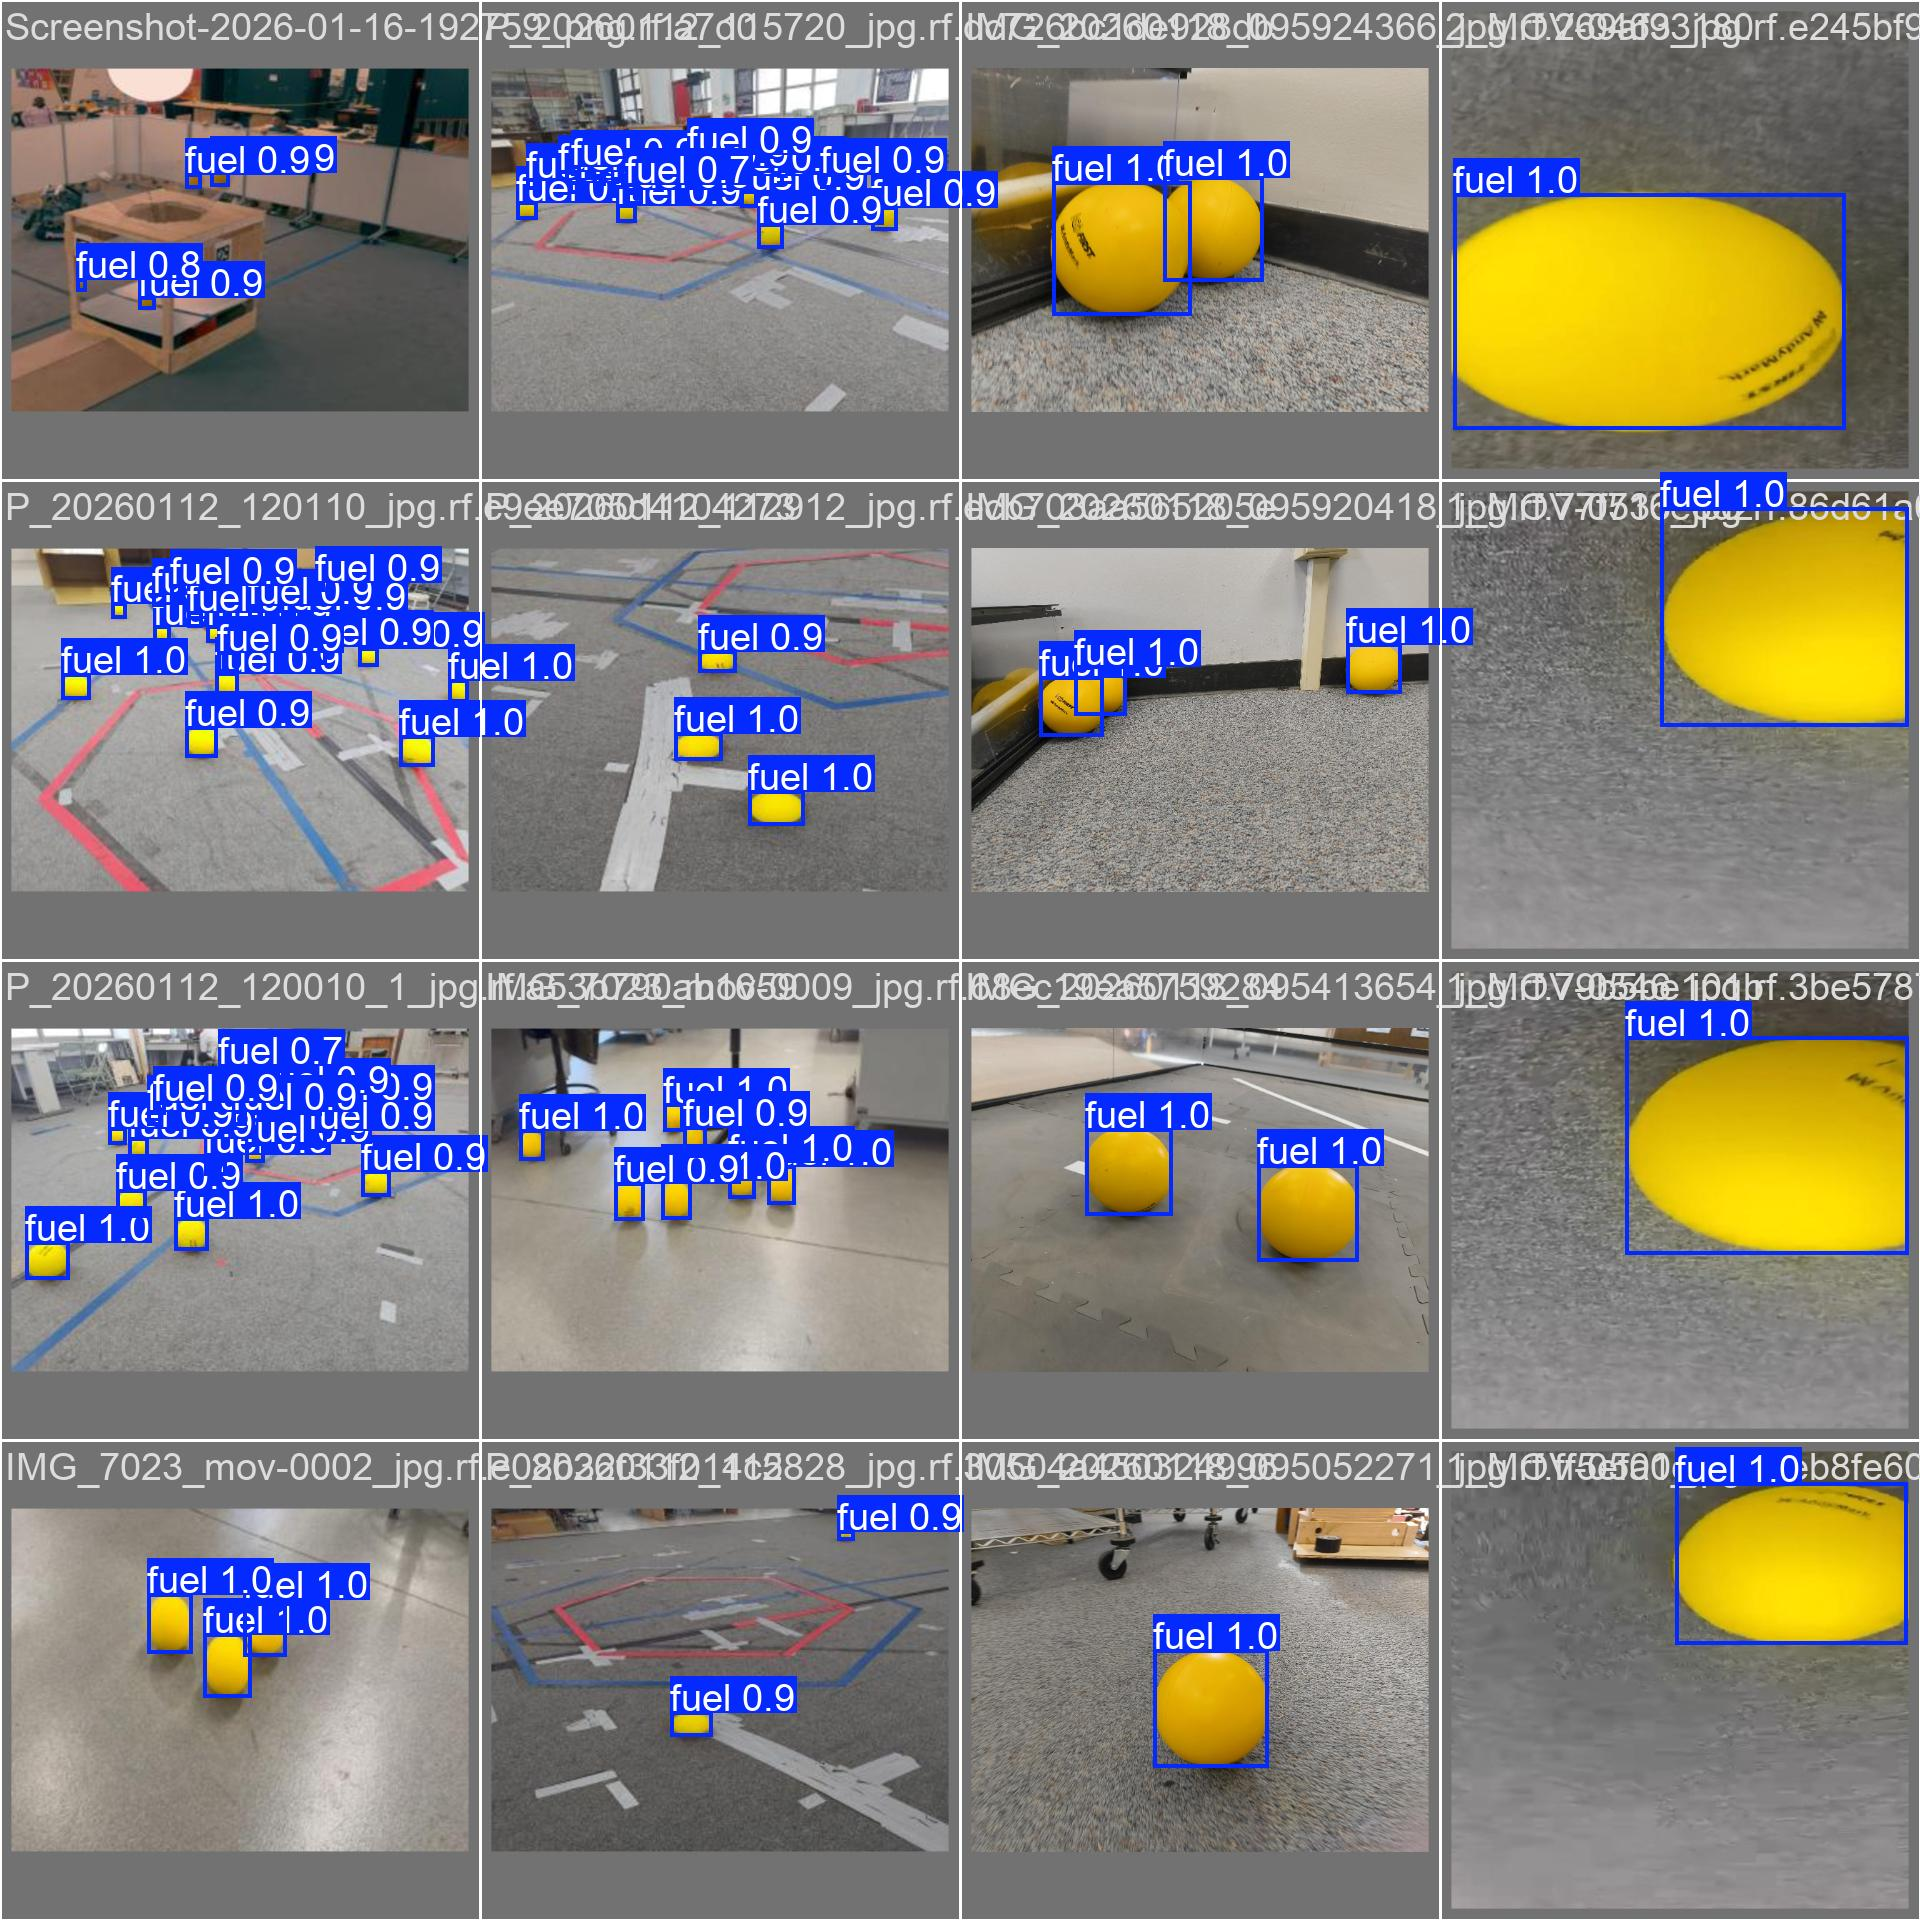

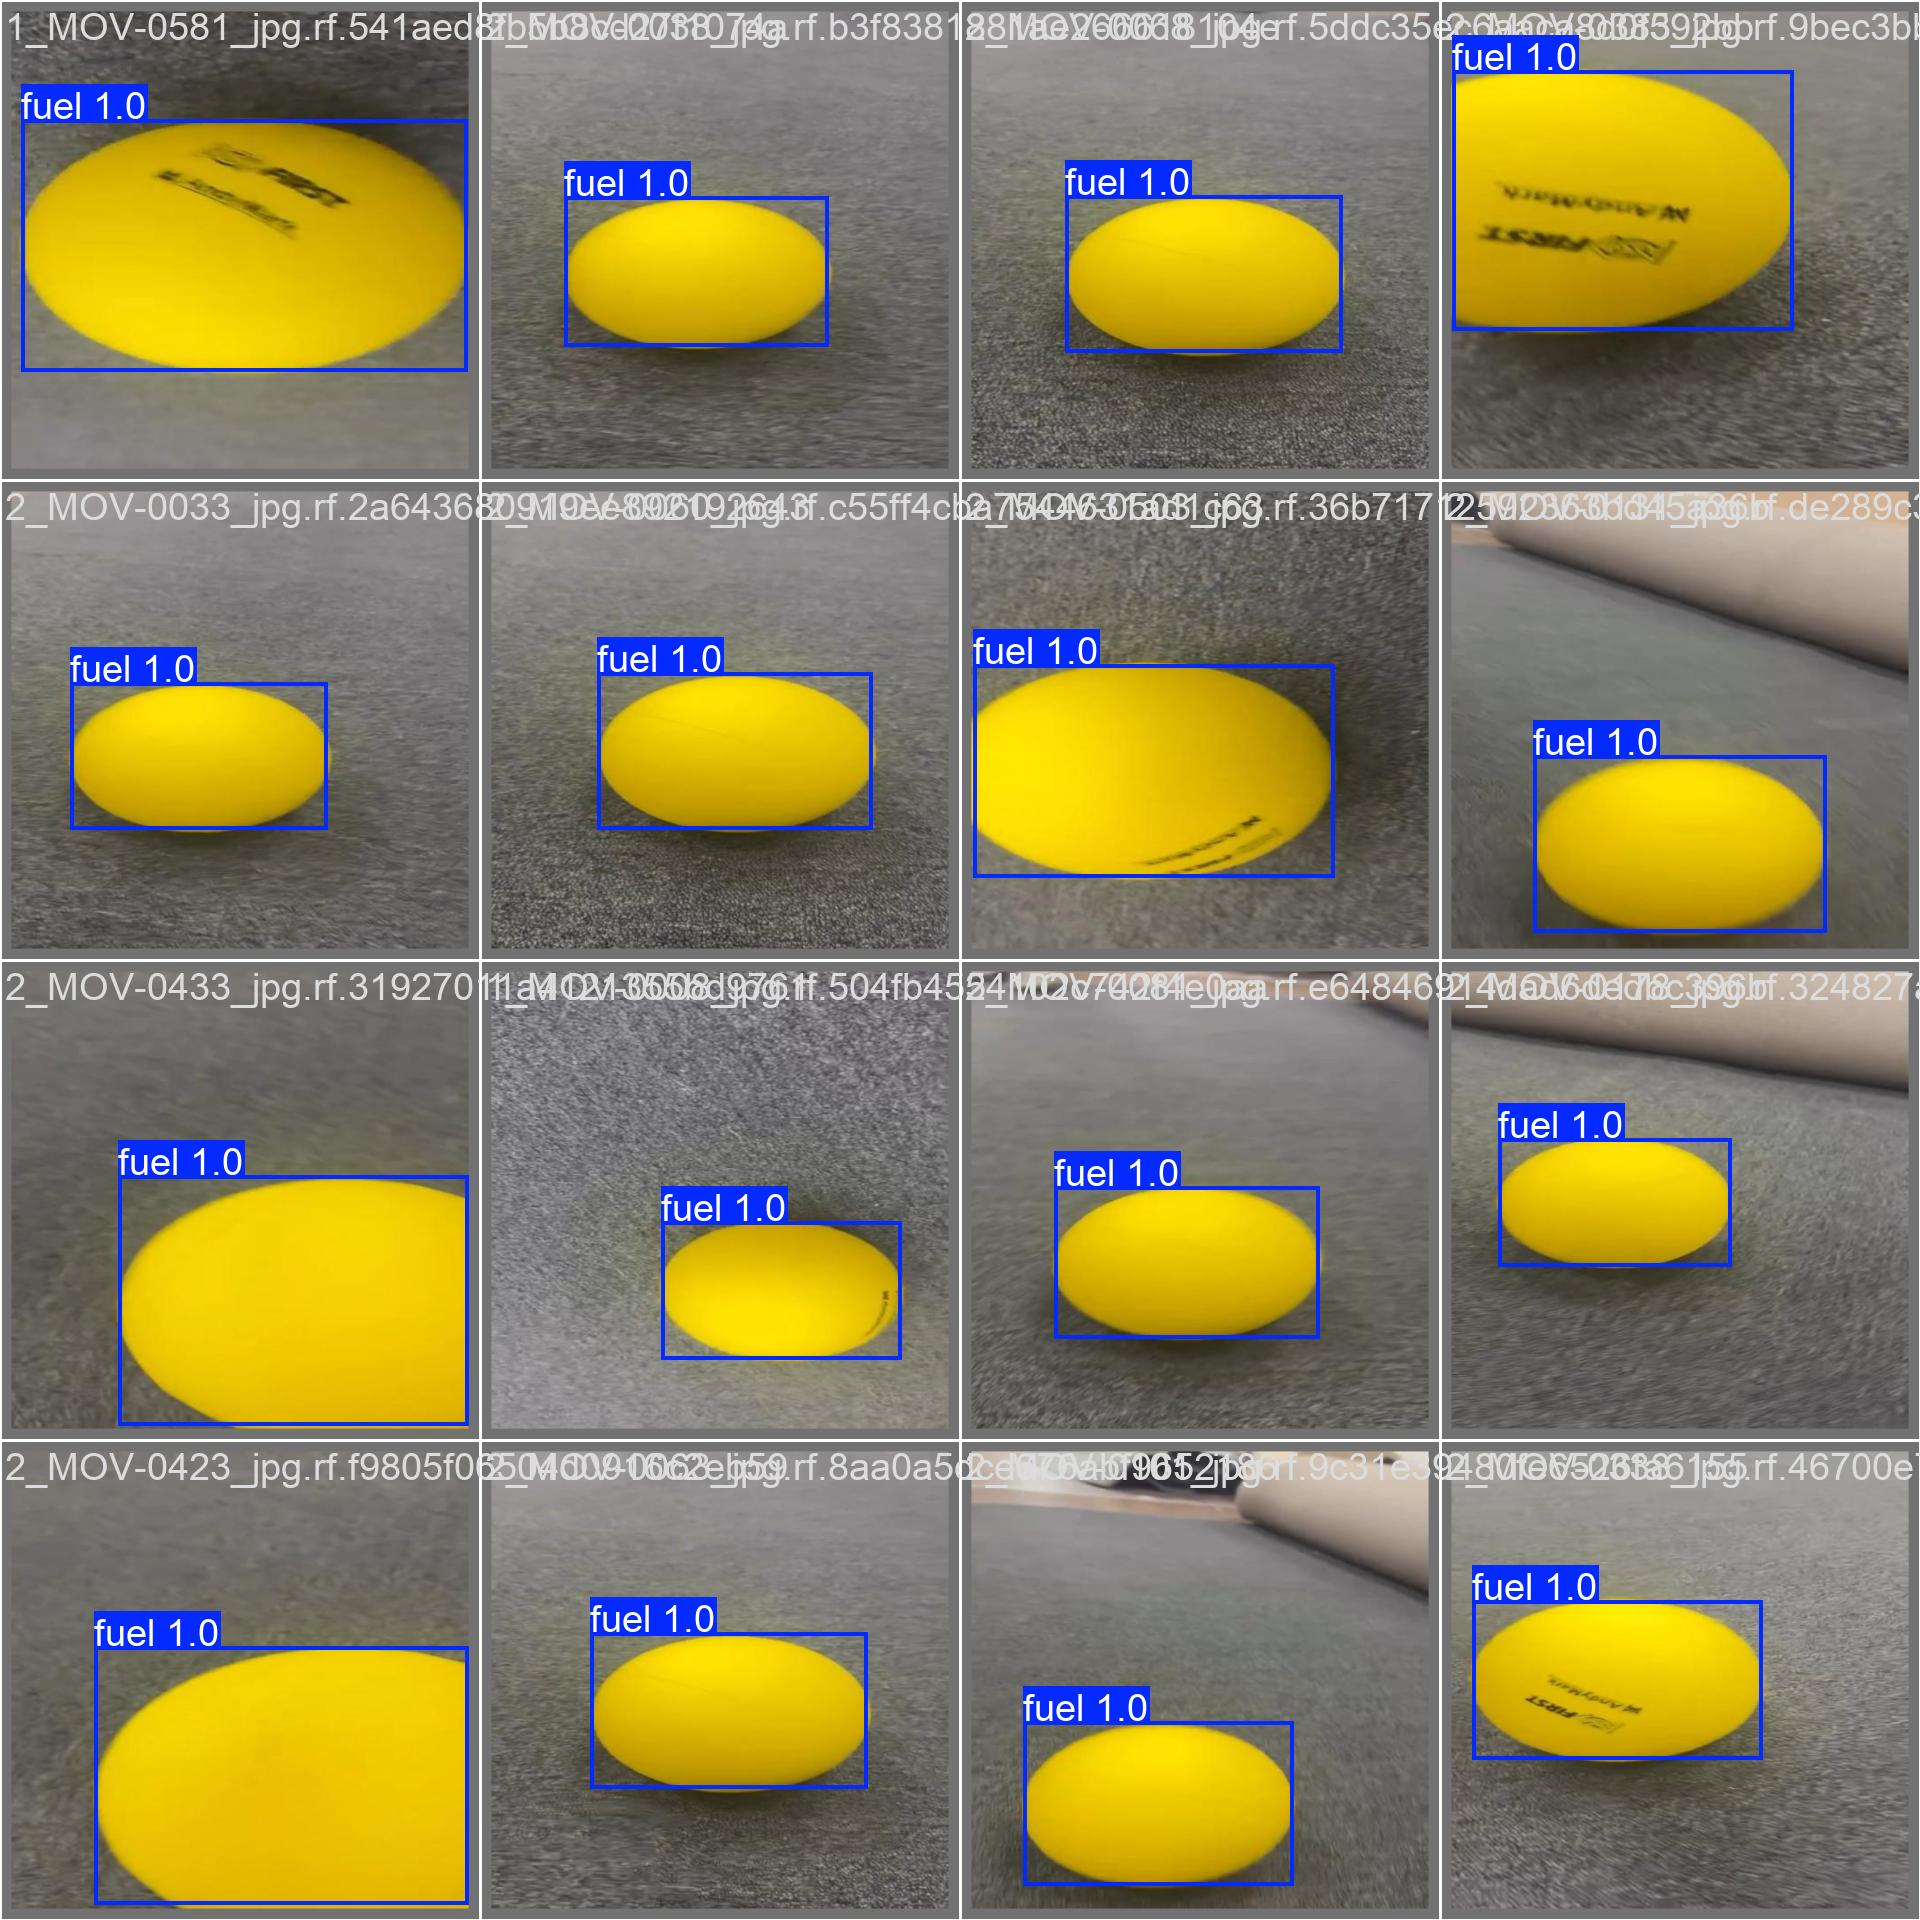

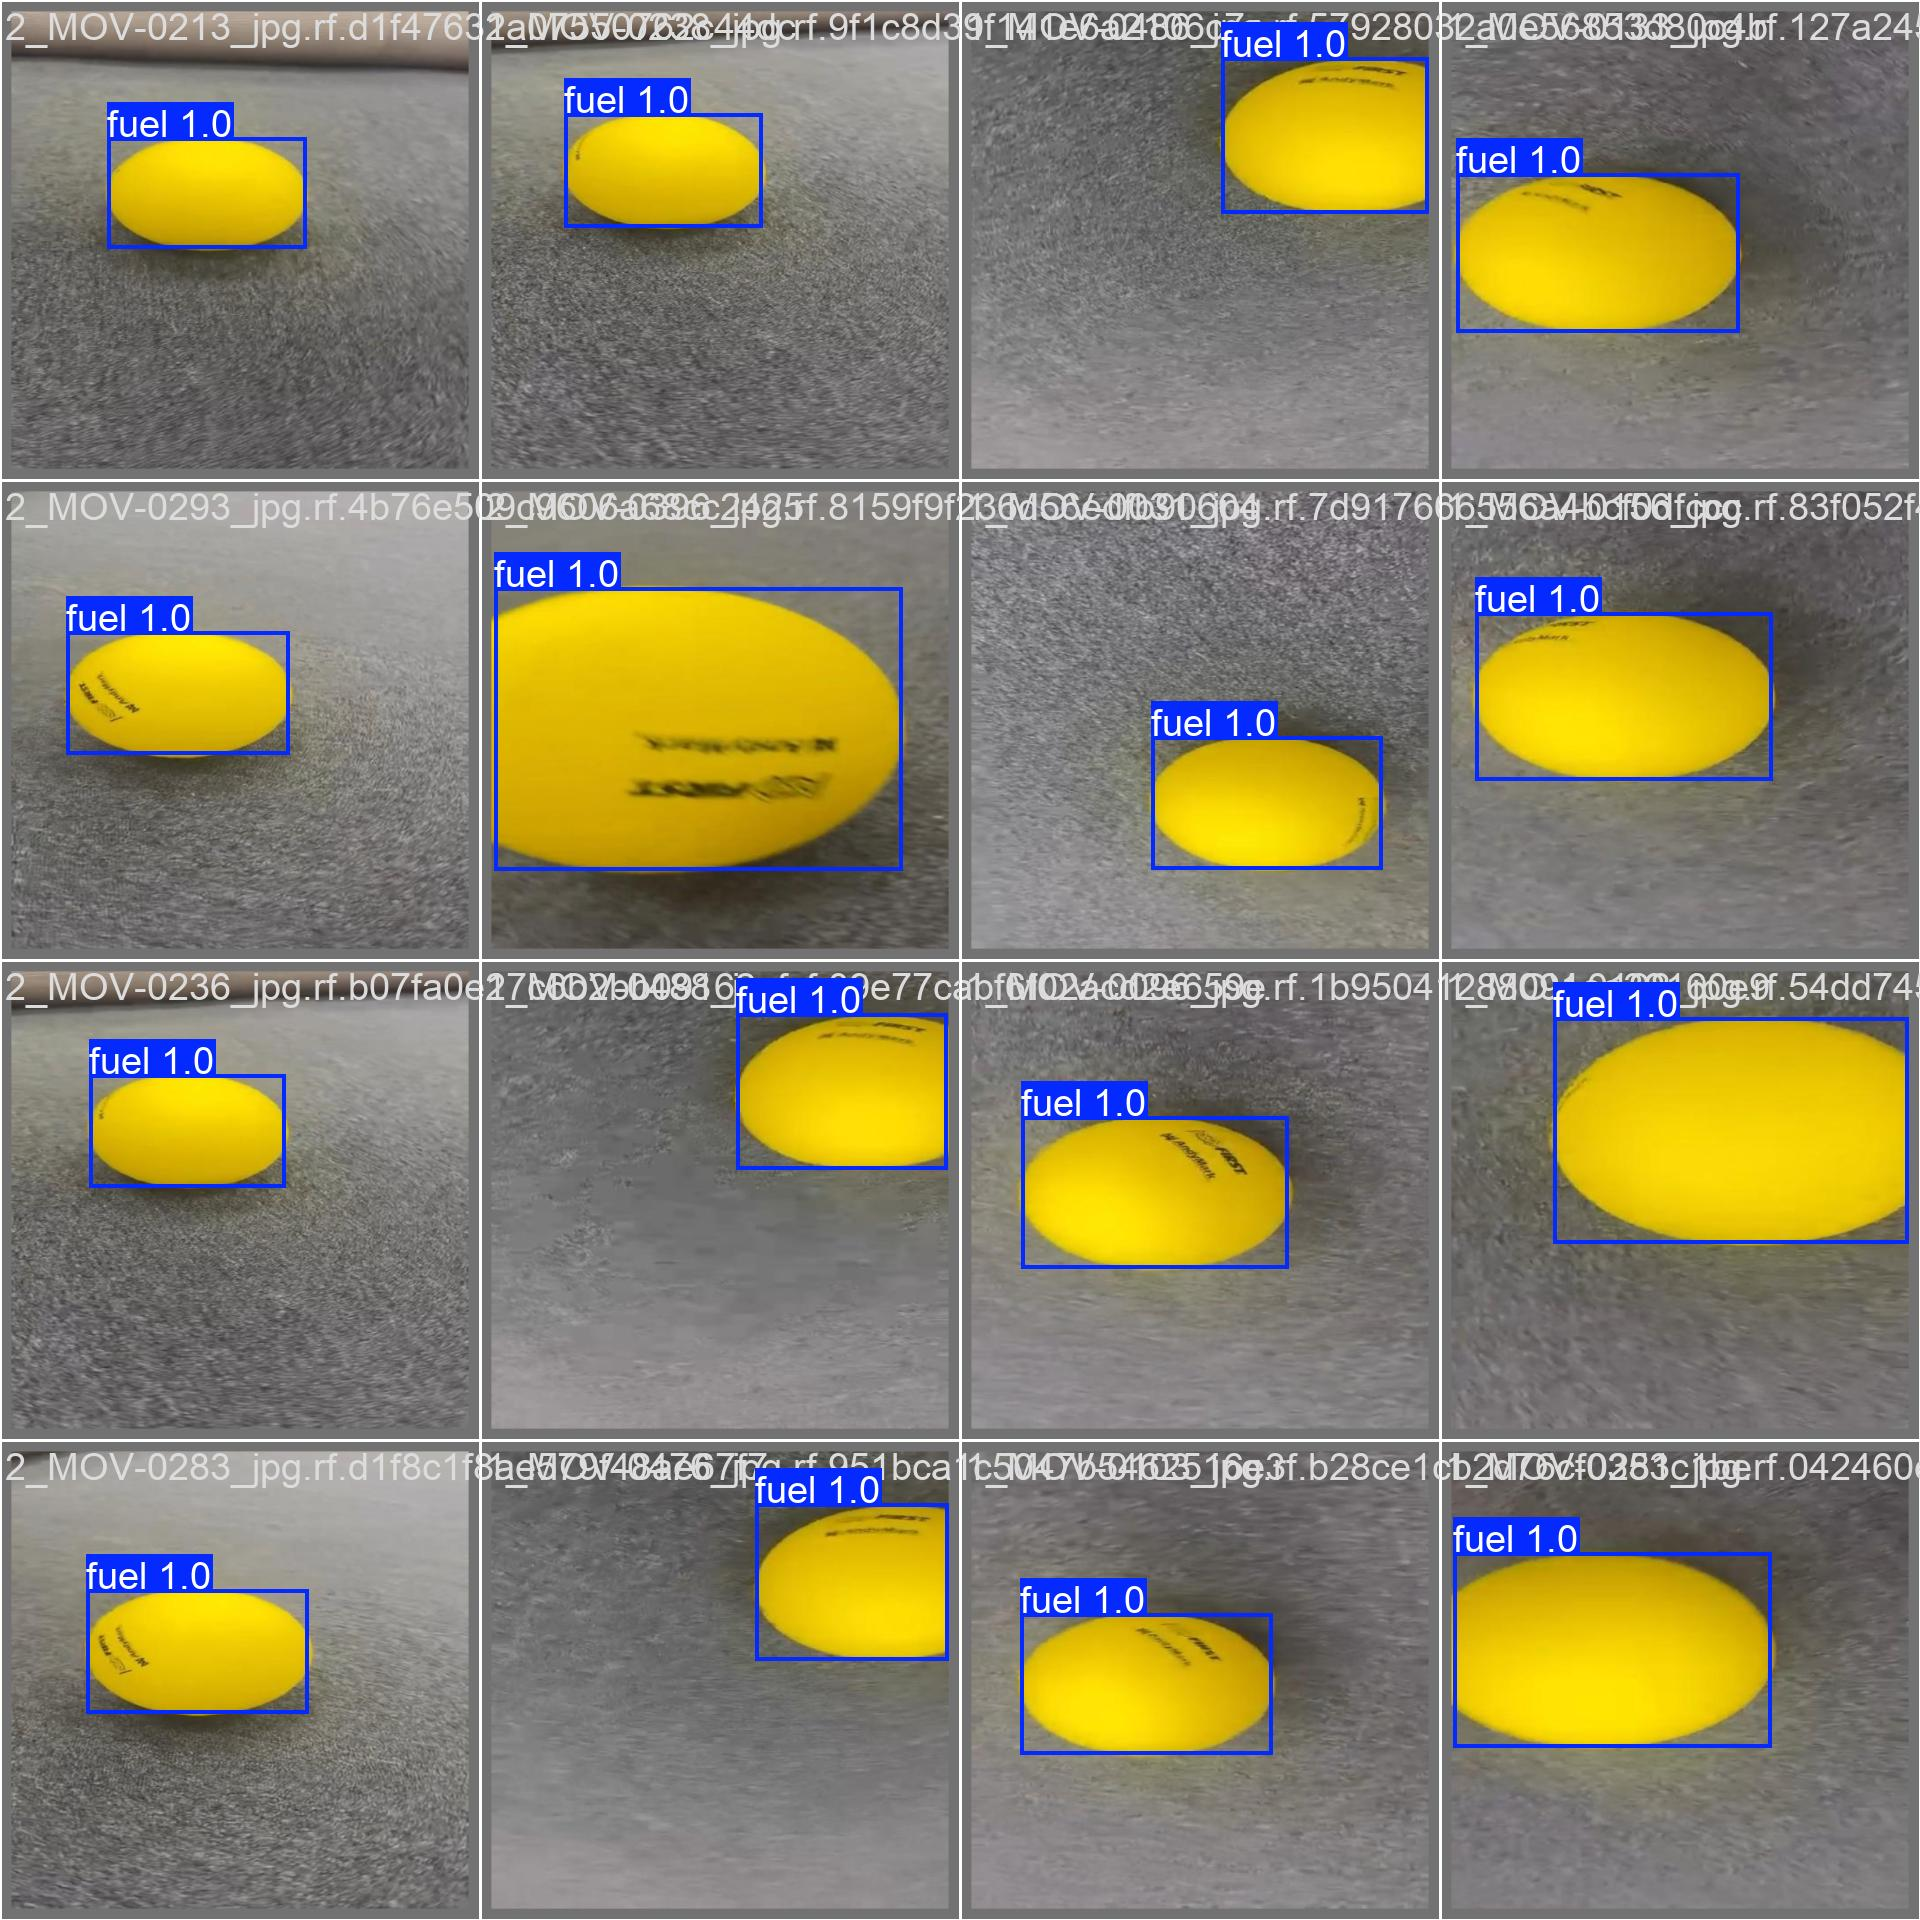

In [5]:
from IPython.display import Image, display
import os
display(Image(filename=f'/Users/rubenhayrapetyan/Downloads/Code/FRC/machine-learning/runs/detect/val/confusion_matrix.png', width=600))
display(Image(filename=f'/Users/rubenhayrapetyan/Downloads/Code/FRC/machine-learning/runs/detect/val/BoxPR_curve.png', width=600))
display(Image(filename=f'/Users/rubenhayrapetyan/Downloads/Code/FRC/machine-learning/runs/detect/val/val_batch0_pred.jpg', width=600))
display(Image(filename=f'/Users/rubenhayrapetyan/Downloads/Code/FRC/machine-learning/runs/detect/val/val_batch1_pred.jpg', width=600))
display(Image(filename=f'/Users/rubenhayrapetyan/Downloads/Code/FRC/machine-learning/runs/detect/val/val_batch2_pred.jpg', width=600))
